In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from scipy.optimize import minimize

In [2]:
# LOAD THE DATA
merged = pd.read_csv("nypd_merged_2025.csv")
deployment = pd.read_csv('nypd_deployment_2025.csv')

/tmp/ipykernel_39410/4220469502.py:2: DtypeWarning: Columns (0: VIPER) have mixed types. Specify dtype option on import or set low_memory=False.
  merged = pd.read_csv("nypd_merged_2025.csv")


In [3]:
deployment = pd.read_csv('nypd_deployment_2025.csv')
deployment.columns = deployment.columns.str.lower()
deployment['arrest_precinct'] = pd.to_numeric(deployment['command'], errors='coerce')
deployment.loc[deployment['command'] == 'Central Park', 'arrest_precinct'] = 22

In [4]:
print(merged.columns.tolist())

['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC', 'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT', 'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD', 'Y_COORD_CD', 'LATITUDE', 'LONGITUDE', 'YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'WEEKEND', 'LAW_CAT_CD_9', 'LAW_CAT_CD_F', 'LAW_CAT_CD_I', 'LAW_CAT_CD_M', 'LAW_CAT_CD_V', 'LAW_CAT_CD_NAN', 'ARREST_BORO_B', 'ARREST_BORO_K', 'ARREST_BORO_M', 'ARREST_BORO_Q', 'ARREST_BORO_S', 'TOTAL', '% OF COMMAND', 'BUREAU', 'VIPER']


NEED TO ALSO LOAD THE PRECINT DATASET SO WE CAN MAP GRID CELLS TO THE NEAREST PRECINT.. POTENTIAL CODE BELOW ONCE WE HAVE IT!

To estimate deployment influence, you must transform raw points into a Density Map.
- Define a Grid: Create a bounding box for NYC and divide it into cells 
- Nearest Precinct: Calculate the centroid of each cell and find the Euclidean distance to the nearest Precinct station.
- Map Deployment: Merge your parsed PDF data (officers per precinct) to each grid cell based on its assigned precinct.

In [5]:
precinct_locations = merged.groupby('ARREST_PRECINCT').agg(
    precinct_lat=('LATITUDE', 'mean'),
    precinct_lon=('LONGITUDE', 'mean'),
    officers_assigned=('TOTAL', 'first')
).reset_index().rename(columns={'ARREST_PRECINCT': 'precinct'})

print(precinct_locations.head())
print("Shape:", precinct_locations.shape)

   precinct  precinct_lat  precinct_lon  officers_assigned
0         1     40.709592    -73.992684                4.0
1         5     40.716605    -73.999003                1.0
2         6     40.733306    -74.001720                4.0
3         7     40.716886    -73.985133                0.0
4         9     40.726595    -73.985381                1.0
Shape: (79, 4)


In [6]:
# Create grid cells from latitude/longitude

#LAT LONG TO NUMERIC
merged['LATITUDE'] = pd.to_numeric(merged['LATITUDE'], errors='coerce')
merged['LONGITUDE'] = pd.to_numeric(merged['LONGITUDE'], errors='coerce')

#DROP BAD COORDINATES
merged = merged.dropna(subset=['LATITUDE', 'LONGITUDE'])
merged = merged[(merged['LATITUDE'] != 0) & (merged['LONGITUDE'] != 0)]

#GRID CELLS
merged['lat_grid'] = merged['LATITUDE'].round(2)
merged['lon_grid'] = merged['LONGITUDE'].round(2)

#GRID ID
merged['grid_id'] = (
    merged['lat_grid'].astype(str) + "_" + merged['lon_grid'].astype(str)
)

print(merged[['LATITUDE', 'LONGITUDE', 'lat_grid', 'lon_grid', 'grid_id']].head())
print("Unique grid cells:", merged['grid_id'].nunique())

    LATITUDE  LONGITUDE  lat_grid  lon_grid       grid_id
0  40.818795 -73.922124     40.82    -73.92  40.82_-73.92
1  40.581725 -74.108439     40.58    -74.11  40.58_-74.11
2  40.740148 -73.790383     40.74    -73.79  40.74_-73.79
3  40.680077 -73.775929     40.68    -73.78  40.68_-73.78
4  40.798243 -73.952462     40.80    -73.95   40.8_-73.95
Unique grid cells: 905


In [7]:
grid_points = merged[["grid_id", "lat_grid", "lon_grid"]].drop_duplicates().dropna()

precinct_coords = np.radians(precinct_locations[["precinct_lat", "precinct_lon"]])
grid_coords = np.radians(grid_points[["lat_grid", "lon_grid"]])

tree = BallTree(precinct_coords, metric="haversine")
dist, ind = tree.query(grid_coords, k=1)

grid_points["nearest_precinct"] = precinct_locations.iloc[ind.flatten()]["precinct"].values
grid_points["estimated_officers"] = precinct_locations.iloc[ind.flatten()]["officers_assigned"].values

print(grid_points.head())

        grid_id  lat_grid  lon_grid  nearest_precinct  estimated_officers
0  40.82_-73.92     40.82    -73.92                40                22.0
1  40.58_-74.11     40.58    -74.11               122                 0.0
2  40.74_-73.79     40.74    -73.79               107                 1.0
3  40.68_-73.78     40.68    -73.78               113                14.0
4   40.8_-73.95     40.80    -73.95                28                10.0


In [9]:
# Remove duplicate merge columns from previous runs
merged = merged.drop(
    columns=[
        'nearest_precinct', 'estimated_officers',
        'nearest_precinct_x', 'estimated_officers_x',
        'nearest_precinct_y', 'estimated_officers_y'
    ],
    errors='ignore'
)

# Merge clean grid info back in
merged = merged.merge(
    grid_points[['grid_id', 'nearest_precinct', 'estimated_officers']],
    on='grid_id',
    how='left'
)

print([c for c in merged.columns if "precinct" in c.lower() or "officer" in c.lower()])

['ARREST_PRECINCT', 'nearest_precinct', 'estimated_officers']


In [11]:
merged = merged.merge(
    grid_points[['grid_id', 'nearest_precinct', 'estimated_officers']],
    on='grid_id',
    how='left'
)

print([c for c in merged.columns if "precinct" in c.lower() or "officer" in c.lower()])

# Aggregate arrests to daily grid level
daily_grid = merged.groupby(
    ['grid_id', 'ARREST_DATE']
).agg({
    'ARREST_KEY': 'count',
    'ARREST_PRECINCT': 'first',
    'ARREST_BORO': 'first',
    'nearest_precinct': 'first',
    'estimated_officers': 'first',
    'TOTAL': 'first',
    '% OF COMMAND': 'first',
    'BUREAU': 'first',
    'VIPER': 'first'
}).reset_index()

daily_grid = daily_grid.rename(columns={
    'ARREST_KEY': 'crime_count',
    'TOTAL': 'total',
    '% OF COMMAND': '% of command',
    'BUREAU': 'bureau',
    'VIPER': 'viper'
})

print(daily_grid.head())
print("Shape:", daily_grid.shape)

['ARREST_PRECINCT', 'nearest_precinct_x', 'estimated_officers_x', 'nearest_precinct_y', 'estimated_officers_y', 'nearest_precinct', 'estimated_officers']
       grid_id ARREST_DATE  crime_count  ARREST_PRECINCT ARREST_BORO  \
0  40.51_-74.2  2023-02-22            1              123           S   
1  40.51_-74.2  2024-03-01            1              123           S   
2  40.51_-74.2  2024-06-04            2              123           S   
3  40.51_-74.2  2024-07-16            1              123           S   
4  40.51_-74.2  2024-07-30            1              123           S   

   nearest_precinct  estimated_officers  total  % of command bureau  viper  
0               123                 2.0    2.0           1.8   PBSI  False  
1               123                 2.0    2.0           1.8   PBSI  False  
2               123                 2.0    2.0           1.8   PBSI  False  
3               123                 2.0    2.0           1.8   PBSI  False  
4               123         

In [12]:
daily_grid = daily_grid[daily_grid['grid_id'] != '0.0_0.0']

daily_grid['ARREST_DATE'] = pd.to_datetime(daily_grid['ARREST_DATE'])
daily_grid['month'] = daily_grid['ARREST_DATE'].dt.month
daily_grid['day_of_week'] = daily_grid['ARREST_DATE'].dt.dayofweek
daily_grid['weekend'] = daily_grid['day_of_week'].isin([5, 6]).astype(int)
daily_grid['week_of_year'] = daily_grid['ARREST_DATE'].dt.isocalendar().week.astype(int)
daily_grid['year'] = daily_grid['ARREST_DATE'].dt.year

daily_grid = daily_grid.sort_values(['grid_id', 'ARREST_DATE'])
daily_grid['lag_1d']  = daily_grid.groupby('grid_id')['crime_count'].shift(1)
daily_grid['lag_7d']  = daily_grid.groupby('grid_id')['crime_count'].shift(7)
daily_grid['lag_30d'] = daily_grid.groupby('grid_id')['crime_count'].shift(30)
daily_grid['rolling_7d_mean']  = daily_grid.groupby('grid_id')['crime_count'].transform(lambda x: x.shift(1).rolling(7).mean())
daily_grid['rolling_30d_mean'] = daily_grid.groupby('grid_id')['crime_count'].transform(lambda x: x.shift(1).rolling(30).mean())

daily_grid = daily_grid.dropna(subset=['lag_1d', 'lag_7d', 'lag_30d', 'bureau'])

print("Shape:", daily_grid.shape)
print("\nDate range:", daily_grid['ARREST_DATE'].min(), "→", daily_grid['ARREST_DATE'].max())
print("\nMissing values:\n", daily_grid.isnull().sum())

Shape: (252648, 21)

Date range: 2023-01-31 00:00:00 → 2025-12-31 00:00:00

Missing values:
 grid_id                 0
ARREST_DATE             0
crime_count             0
ARREST_PRECINCT         0
ARREST_BORO             0
nearest_precinct        0
estimated_officers    994
total                   0
% of command            0
bureau                  0
viper                   0
month                   0
day_of_week             0
weekend                 0
week_of_year            0
year                    0
lag_1d                  0
lag_7d                  0
lag_30d                 0
rolling_7d_mean         0
rolling_30d_mean        0
dtype: int64


In [13]:
daily_grid = daily_grid.dropna(subset=['nearest_precinct', 'estimated_officers'])
print("Final shape:", daily_grid.shape)

Final shape: (251654, 21)


Train: 201361 rows | Test: 50293 rows
Cutoff date: 2025-06-12

RF (no deployment):
  MAE: 1.3570
  R2:  0.4994

RF (with deployment):
  MAE: 1.3564
  R2:  0.4998

XGB (no deployment):
  MAE: 1.3544
  R2:  0.5054

XGB (with deployment):
  MAE: 1.3551
  R2:  0.5053

                 Model    MAE     R2
   RF (no deployment) 1.3570 0.4994
 RF (with deployment) 1.3564 0.4998
  XGB (no deployment) 1.3544 0.5054
XGB (with deployment) 1.3551 0.5053


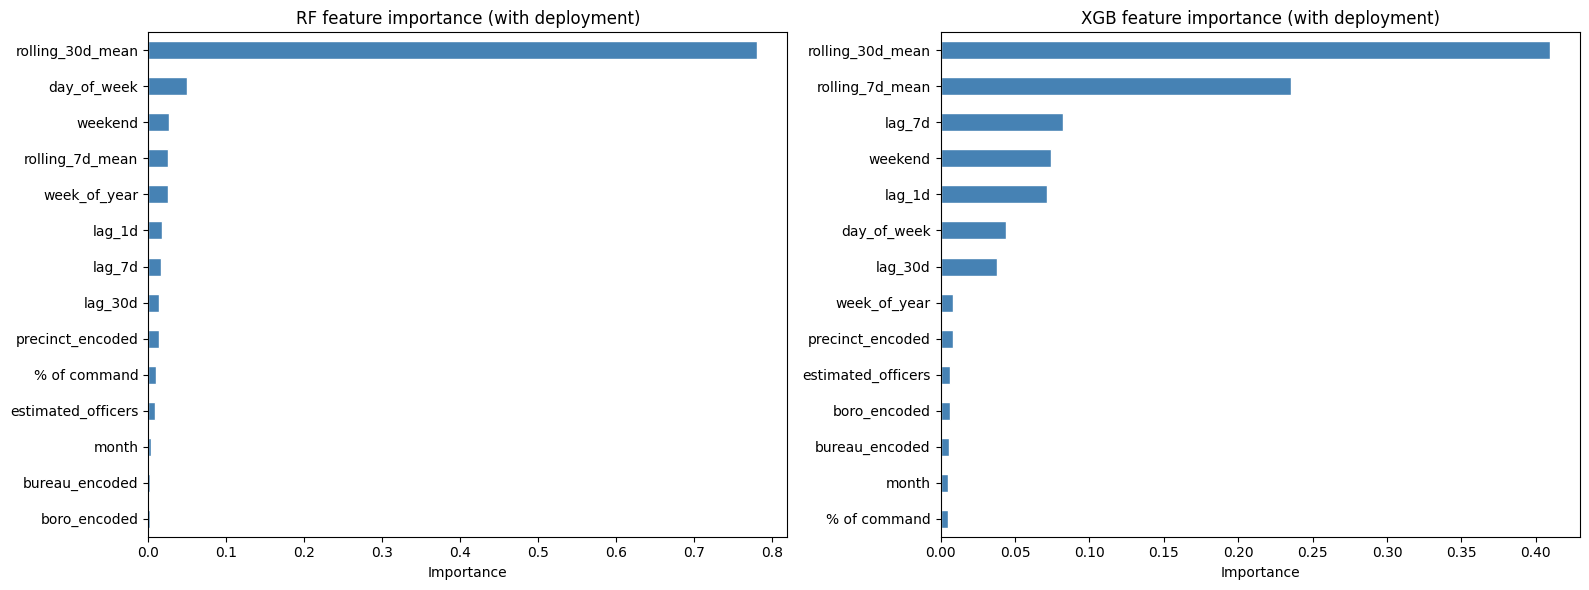

In [14]:
# ── 1. encode categoricals ───────────────────────────────────────────────────
le_boro = LabelEncoder()
le_bureau = LabelEncoder()
daily_grid['boro_encoded'] = le_boro.fit_transform(daily_grid['ARREST_BORO'].astype(str))
daily_grid['precinct_encoded'] = LabelEncoder().fit_transform(daily_grid['nearest_precinct'].astype(str))
daily_grid['bureau_encoded'] = le_bureau.fit_transform(daily_grid['bureau'].astype(str))

# ── 2. feature sets ──────────────────────────────────────────────────────────
base_features = [
    'month', 'day_of_week', 'weekend', 'week_of_year',
    'boro_encoded', 'bureau_encoded', 'precinct_encoded',
    'lag_1d', 'lag_7d', 'lag_30d',
    'rolling_7d_mean', 'rolling_30d_mean'
]


target = 'crime_count'
deployment_features = base_features + ['estimated_officers', '% of command']

# ── 3. time-based train/test split ───────────────────────────────────────────
daily_grid = daily_grid.sort_values('ARREST_DATE')
cutoff = daily_grid['ARREST_DATE'].quantile(0.8)

train = daily_grid[daily_grid['ARREST_DATE'] <= cutoff]
test  = daily_grid[daily_grid['ARREST_DATE'] > cutoff]

X_train_base = train[base_features]
X_test_base  = test[base_features]
X_train_dep  = train[deployment_features]
X_test_dep   = test[deployment_features]
y_train      = train[target]
y_test       = test[target]

print(f"Train: {len(train)} rows | Test: {len(test)} rows")
print(f"Cutoff date: {cutoff.date()}")

# ── 4. random forest without deployment ──────────────────────────────────────
rf_base = RandomForestRegressor(
    n_estimators=50,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=1
)

rf_base.fit(X_train_base, y_train)
rf_base_preds = rf_base.predict(X_test_base)

print("\nRF (no deployment):")
print(f"  MAE: {mean_absolute_error(y_test, rf_base_preds):.4f}")
print(f"  R2:  {r2_score(y_test, rf_base_preds):.4f}")

# ── 5. random forest with deployment ─────────────────────────────────────────
rf_dep = RandomForestRegressor(
    n_estimators=50,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=1
)

rf_dep.fit(X_train_dep, y_train)
rf_dep_preds = rf_dep.predict(X_test_dep)

print("\nRF (with deployment):")
print(f"  MAE: {mean_absolute_error(y_test, rf_dep_preds):.4f}")
print(f"  R2:  {r2_score(y_test, rf_dep_preds):.4f}")

# ── 6. xgboost without deployment ────────────────────────────────────────────
xgb_base = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=1,
    verbosity=0
)
xgb_base.fit(X_train_base, y_train)
xgb_base_preds = xgb_base.predict(X_test_base)

print("\nXGB (no deployment):")
print(f"  MAE: {mean_absolute_error(y_test, xgb_base_preds):.4f}")
print(f"  R2:  {r2_score(y_test, xgb_base_preds):.4f}")

# ── 7. xgboost with deployment ────────────────────────────────────────────────
xgb_dep = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=1,
    verbosity=0
)

xgb_dep.fit(X_train_dep, y_train)
xgb_dep_preds = xgb_dep.predict(X_test_dep)

print("\nXGB (with deployment):")
print(f"  MAE: {mean_absolute_error(y_test, xgb_dep_preds):.4f}")
print(f"  R2:  {r2_score(y_test, xgb_dep_preds):.4f}")

# ── 8. results summary ────────────────────────────────────────────────────────
results = pd.DataFrame({
    'Model': ['RF (no deployment)', 'RF (with deployment)', 
              'XGB (no deployment)', 'XGB (with deployment)'],
    'MAE':   [mean_absolute_error(y_test, rf_base_preds),
              mean_absolute_error(y_test, rf_dep_preds),
              mean_absolute_error(y_test, xgb_base_preds),
              mean_absolute_error(y_test, xgb_dep_preds)],
    'R2':    [r2_score(y_test, rf_base_preds),
              r2_score(y_test, rf_dep_preds),
              r2_score(y_test, xgb_base_preds),
              r2_score(y_test, xgb_dep_preds)]
}).round(4)

print("\n", results.to_string(index=False))

# ── 9. feature importance plots ───────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, title, features in [
    (axes[0], rf_dep,  'RF feature importance (with deployment)',  deployment_features),
    (axes[1], xgb_dep, 'XGB feature importance (with deployment)', deployment_features)
]:
    importances = pd.Series(model.feature_importances_, index=features).sort_values()
    importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Importance')
    ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

In [15]:
#what's actually driving predictions
importances_xgb = pd.Series(
    xgb_dep.feature_importances_, 
    index=deployment_features
).sort_values(ascending=False)

print("XGB feature importances (with deployment):")
print(importances_xgb.round(4).to_string())

# variance in the target
print("\nCrime count distribution:")
print(daily_grid['crime_count'].describe().round(2))

#date range
print("\nDate range:", daily_grid['ARREST_DATE'].min(), "→", daily_grid['ARREST_DATE'].max())

XGB feature importances (with deployment):
rolling_30d_mean      0.4092
rolling_7d_mean       0.2354
lag_7d                0.0821
weekend               0.0742
lag_1d                0.0718
day_of_week           0.0441
lag_30d               0.0380
week_of_year          0.0082
precinct_encoded      0.0080
estimated_officers    0.0066
boro_encoded          0.0064
bureau_encoded        0.0058
month                 0.0052
% of command          0.0049

Crime count distribution:
count    251654.00
mean          2.87
std           2.96
min           1.00
25%           1.00
50%           2.00
75%           4.00
max         138.00
Name: crime_count, dtype: float64

Date range: 2023-01-31 00:00:00 → 2025-12-31 00:00:00


In [16]:
print(daily_grid['ARREST_DATE'].value_counts().sort_index().head(20))
print("\nUnique dates:", daily_grid['ARREST_DATE'].nunique())
print("Unique grid cells:", daily_grid['grid_id'].nunique())

ARREST_DATE
2023-01-31      8
2023-02-01     21
2023-02-02     34
2023-02-03     41
2023-02-04     54
2023-02-05     60
2023-02-06     70
2023-02-07     82
2023-02-08     89
2023-02-09     90
2023-02-10     96
2023-02-11    109
2023-02-12     91
2023-02-13    105
2023-02-14    122
2023-02-15    127
2023-02-16    129
2023-02-17    129
2023-02-18    115
2023-02-19    110
Name: count, dtype: int64

Unique dates: 1066
Unique grid cells: 730


FOR MODELING TARGET VARIABLE WILL BE CRIME COUNT WITH FEATURES LIKE DEPLOYED FORCES, DAY OF WEEK, MONTH, OTHER TEMPORAL, BOROUGH, PRECINT, LAGGED CRIME (YESTERDAY, 7 DAYS, 30 DAYS)!! RUN A RANDOM FOREST/XGBOOST WITH DEPLOYED FORCES AND WITHOUT
- MAYBE INCLUDE A CONSTRAINT THAT HAS A MINIMUM DEPLOYMENT FLOOR OR PENALTY FOR OVER-CONCENTRATION

I am going to try and do a few things under this text message and you guys let me know what you think.

## NORMALISING DEPLOYMENT AND CREATING 2 SCENATIOS WHERE THERE IS 0 POLICING AND LIMITED POLICIING

In [17]:
##Normalising Deployment
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

daily_grid['deployment_norm'] = scaler.fit_transform(
    daily_grid[['estimated_officers']]
)

deployment_features = base_features + ['deployment_norm']

xgb_dep.fit(X_train_dep, y_train)
baseline_preds = xgb_dep.predict(X_test_dep)


In [20]:
# Baseline prediction
preds_base = xgb_dep.predict(X_test_dep)

# Scenario 1: no deployment
X_test_zero = X_test_dep.copy()
X_test_zero['estimated_officers'] = 0
X_test_zero['% of command'] = 0

preds_zero = xgb_dep.predict(X_test_zero)

# Scenario 2: half deployment
X_test_half = X_test_dep.copy()
X_test_half['estimated_officers'] = X_test_half['estimated_officers'] * 0.5
X_test_half['% of command'] = X_test_half['% of command'] * 0.5

preds_half = xgb_dep.predict(X_test_half)

In [21]:
threshold = np.percentile(preds_base, 90)

hotspots_base = preds_base >= threshold
hotspots_zero = preds_zero >= threshold
hotspots_half = preds_half >= threshold

print("Baseline hotspots:", hotspots_base.sum())
print("Zero deployment hotspots:", hotspots_zero.sum())
print("Half deployment hotspots:", hotspots_half.sum())

print("Still hotspots with zero deployment:", (hotspots_base & hotspots_zero).sum())
print("Still hotspots with half deployment:", (hotspots_base & hotspots_half).sum())

Baseline hotspots: 5030
Zero deployment hotspots: 4942
Half deployment hotspots: 4993
Still hotspots with zero deployment: 4916
Still hotspots with half deployment: 4988


In [22]:
print(f"Percent of baseline hotspots staying hotspots with zero deployment: {(hotspots_base & hotspots_zero).sum() / hotspots_base.sum():.2%}")
print(f"Percent of baseline hotspots staying hotspots with half deployment: {(hotspots_base & hotspots_half).sum() / hotspots_base.sum():.2%}")

Percent of baseline hotspots staying hotspots with zero deployment: 97.73%
Percent of baseline hotspots staying hotspots with half deployment: 99.17%


## CREATING ANOTHER MODEL USING RELATIVE RISK

In [23]:
experiment_grid = daily_grid.copy()

experiment_grid['expected_crime'] = experiment_grid['rolling_30d_mean'].clip(lower=1)

experiment_grid['crime_residual'] = (
    np.log1p(experiment_grid['crime_count']) -
    np.log1p(experiment_grid['expected_crime'])
)

experiment_grid['lag_1d_ratio'] = experiment_grid['lag_1d'] / experiment_grid['expected_crime']
experiment_grid['lag_7d_ratio'] = experiment_grid['lag_7d'] / experiment_grid['expected_crime']
experiment_grid['lag_30d_ratio'] = experiment_grid['lag_30d'] / experiment_grid['expected_crime']

experiment_grid['deployment_norm'] = (
    experiment_grid['estimated_officers'] - experiment_grid['estimated_officers'].min()
) / (
    experiment_grid['estimated_officers'].max() - experiment_grid['estimated_officers'].min()
)

bias_reduced_features = [
    'month', 'day_of_week', 'weekend', 'week_of_year',
    'boro_encoded', 'bureau_encoded', 'precinct_encoded',
    'lag_1d_ratio', 'lag_7d_ratio', 'lag_30d_ratio',
    'rolling_7d_mean', 'rolling_30d_mean',
    'deployment_norm'
]

bias_target = 'crime_residual'

experiment_grid = experiment_grid.sort_values('ARREST_DATE')
cutoff_exp = experiment_grid['ARREST_DATE'].quantile(0.8)

train_exp = experiment_grid[experiment_grid['ARREST_DATE'] <= cutoff_exp]
test_exp = experiment_grid[experiment_grid['ARREST_DATE'] > cutoff_exp]

X_train_bias = train_exp[bias_reduced_features]
X_test_bias = test_exp[bias_reduced_features]
y_train_bias = train_exp[bias_target]
y_test_bias = test_exp[bias_target]

xgb_bias_reduced = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=1,
    verbosity=0
)

xgb_bias_reduced.fit(X_train_bias, y_train_bias)
bias_preds = xgb_bias_reduced.predict(X_test_bias)

print("Bias-Reduced XGB Model:")
print(f"MAE: {mean_absolute_error(y_test_bias, bias_preds):.4f}")
print(f"R2:  {r2_score(y_test_bias, bias_preds):.4f}")

Bias-Reduced XGB Model:
MAE: 0.3125
R2:  0.0677


In [24]:
bias_importance = pd.Series(
    xgb_bias_reduced.feature_importances_,
    index=bias_reduced_features
).sort_values(ascending=False)

print(bias_importance.round(4))

weekend             0.2534
day_of_week         0.2433
rolling_30d_mean    0.1805
rolling_7d_mean     0.0692
lag_1d_ratio        0.0472
lag_7d_ratio        0.0435
week_of_year        0.0336
bureau_encoded      0.0322
boro_encoded        0.0246
month               0.0234
precinct_encoded    0.0204
deployment_norm     0.0150
lag_30d_ratio       0.0135
dtype: float32


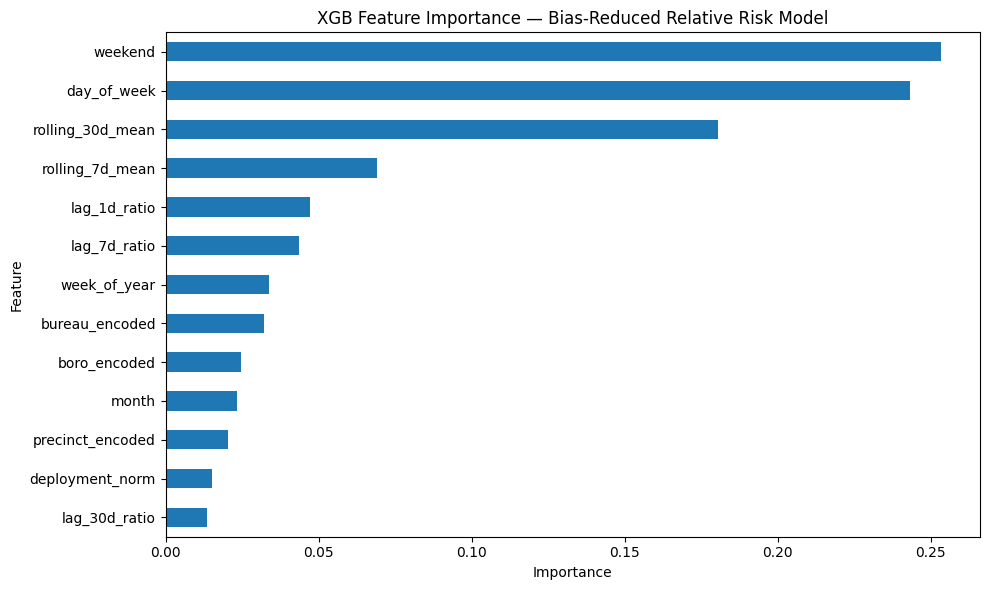

In [25]:
bias_importance = pd.Series(
    xgb_bias_reduced.feature_importances_,
    index=bias_reduced_features
).sort_values()

plt.figure(figsize=(10, 6))
bias_importance.plot(kind='barh')

plt.title('XGB Feature Importance — Bias-Reduced Relative Risk Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('bias_reduced_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()